# Neural Network from Scratch
Two-layer neural network (784 → 10 → 10) trained on MNIST digits using pure NumPy.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data Loading & Preprocessing

In [4]:
data = pd.read_csv('Data/train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data = np.array(data)
np.random.seed(42)
np.random.shuffle(data)

m, n = data.shape

data_dev   = data[:1000].T
y_dev      = data_dev[0].astype(int)
x_dev      = data_dev[1:] / 255.0   

data_train = data[1000:].T
y_train    = data_train[0].astype(int)
x_train    = data_train[1:] / 255.0 

print(f'Train: {x_train.shape[1]} samples | Dev: {x_dev.shape[1]} samples | Features: {x_train.shape[0]}')

Train: 41000 samples | Dev: 1000 samples | Features: 784


## 2. Network Architecture
Architecture: `784 → 10 (ReLU) → 10 (Softmax)`

In [6]:
def initialize_parameters(n_input=784, n_hidden=10, n_output=10):
    W1 = np.random.randn(n_hidden, n_input) * np.sqrt(2.0 / n_input)
    b1 = np.zeros((n_hidden, 1))
    W2 = np.random.randn(n_output, n_hidden) * np.sqrt(2.0 / n_hidden)
    b2 = np.zeros((n_output, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

## 3. Forward & Backward Propagation

In [7]:
def relu(Z):
    return np.maximum(0, Z)

def relu_deriv(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

In [8]:
def one_hot(Y, n_classes=10):
    m = Y.shape[0]
    one_hot_Y = np.zeros((n_classes, m))
    one_hot_Y[Y, np.arange(m)] = 1
    return one_hot_Y

In [9]:
def forward_prop(X, params):
    Z1 = params["W1"] @ X + params["b1"]
    A1 = relu(Z1)
    Z2 = params["W2"] @ A1 + params["b2"]
    A2 = softmax(Z2)
    return A2, {"Z1": Z1, "A1": A1}

In [10]:
def back_prop(A2, cache, params, X, Y):
    m = X.shape[1]
    Z1, A1 = cache["Z1"], cache["A1"]

    dZ2 = A2 - one_hot(Y)              
    dW2 = (1/m) * dZ2 @ A1.T
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = params["W2"].T @ dZ2
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = (1/m) * dZ1 @ X.T
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

## 4. Training

In [11]:
def update_parameters(params, grads, lr):
    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"]
    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"]
    return params

In [13]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)

def compute_accuracy(A2, Y):
    return np.mean(get_predictions(A2) == Y)

def compute_loss(A2, Y):
    log_probs = -np.log(np.clip(A2, 1e-8, 1.0))
    return np.mean(np.sum(log_probs * one_hot(Y), axis=0))

In [14]:
def gradient_descent(X_train, Y_train, X_val, Y_val, iterations=500, lr=0.1):
    params = initialize_parameters()
    history = {"iter": [], "loss": [], "train_acc": [], "val_acc": []}

    log_every = 50
    for i in range(iterations):
        A2, cache = forward_prop(X_train, params)
        grads = back_prop(A2, cache, params, X_train, Y_train)
        params = update_parameters(params, grads, lr)

        if i % log_every == 0:
            loss      = compute_loss(A2, Y_train)
            train_acc = compute_accuracy(A2, Y_train)
            A2_val, _ = forward_prop(X_val, params)
            val_acc   = compute_accuracy(A2_val, Y_val)

            history["iter"].append(i)
            history["loss"].append(loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)
            print(f'Iter {i:4d} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}')

    return params, history

In [15]:
params, history = gradient_descent(
    x_train, y_train,
    x_dev,   y_dev,
    iterations=1000,
    lr=0.1
)

Iter    0 | Loss: 2.4293 | Train: 0.1047 | Val: 0.1390
Iter   50 | Loss: 1.0303 | Train: 0.7111 | Val: 0.7320
Iter  100 | Loss: 0.7065 | Train: 0.7983 | Val: 0.8070
Iter  150 | Loss: 0.5750 | Train: 0.8360 | Val: 0.8600
Iter  200 | Loss: 0.5004 | Train: 0.8566 | Val: 0.8840
Iter  250 | Loss: 0.4526 | Train: 0.8707 | Val: 0.8930
Iter  300 | Loss: 0.4206 | Train: 0.8794 | Val: 0.9040
Iter  350 | Loss: 0.3981 | Train: 0.8858 | Val: 0.9070
Iter  400 | Loss: 0.3818 | Train: 0.8909 | Val: 0.9130
Iter  450 | Loss: 0.3694 | Train: 0.8942 | Val: 0.9150
Iter  500 | Loss: 0.3596 | Train: 0.8965 | Val: 0.9180
Iter  550 | Loss: 0.3516 | Train: 0.8985 | Val: 0.9180
Iter  600 | Loss: 0.3450 | Train: 0.9008 | Val: 0.9170
Iter  650 | Loss: 0.3393 | Train: 0.9026 | Val: 0.9190
Iter  700 | Loss: 0.3343 | Train: 0.9040 | Val: 0.9200
Iter  750 | Loss: 0.3299 | Train: 0.9051 | Val: 0.9180
Iter  800 | Loss: 0.3259 | Train: 0.9062 | Val: 0.9190
Iter  850 | Loss: 0.3223 | Train: 0.9076 | Val: 0.9190
Iter  900 

## 5. Results & Visualization

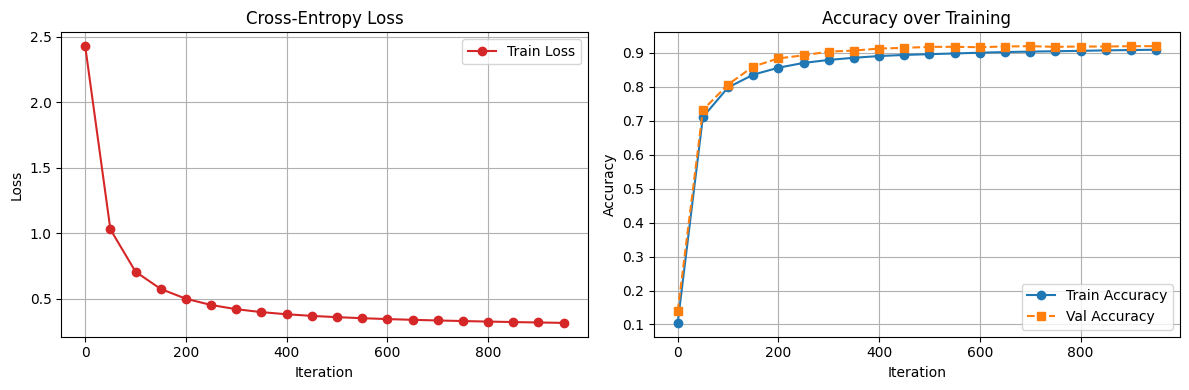

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
iterations = history["iter"]

axes[0].plot(iterations, history['loss'], marker='o', color='tab:red', label='Train Loss')
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(iterations, history['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(iterations, history['val_acc'],   marker='s', linestyle='--', label='Val Accuracy')
axes[1].set_title('Accuracy over Training')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
A2_val, _ = forward_prop(x_dev, params)
final_acc = compute_accuracy(A2_val, y_dev)
print(f'Final Validation Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)')

Final Validation Accuracy: 0.9200 (92.00%)


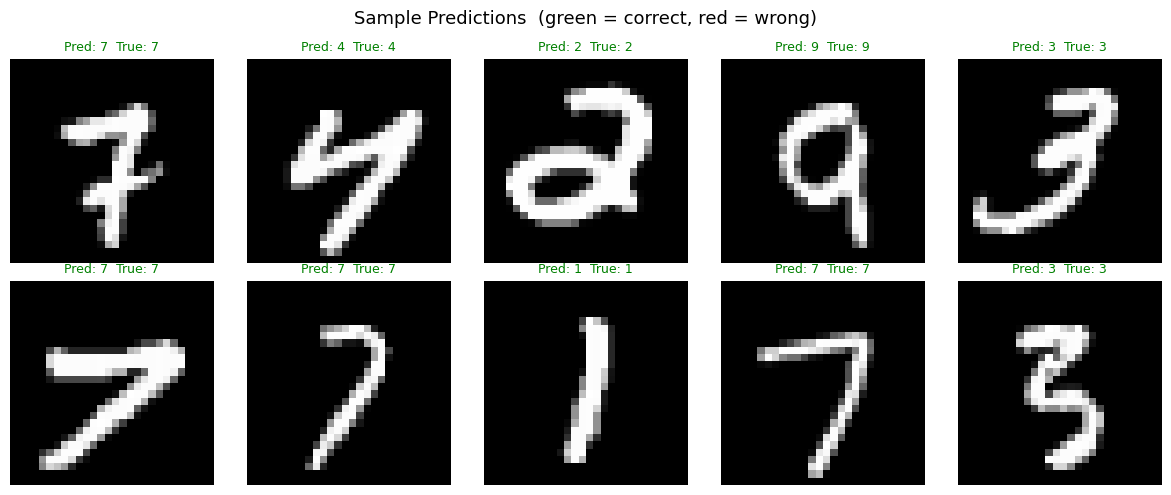

In [18]:
def show_predictions(X, Y, params, n=10):
    """Display n random dev-set samples with predicted vs actual label."""
    A2, _ = forward_prop(X, params)
    preds  = get_predictions(A2)
    indices = np.random.choice(X.shape[1], n, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for ax, idx in zip(axes.flat, indices):
        img   = X[:, idx].reshape(28, 28)
        color = 'green' if preds[idx] == Y[idx] else 'red'
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Pred: {preds[idx]}  True: {Y[idx]}', color=color, fontsize=9)
        ax.axis('off')

    plt.suptitle('Sample Predictions  (green = correct, red = wrong)', fontsize=13)
    plt.tight_layout()
    plt.show()

show_predictions(x_dev, y_dev, params)